# Classificação da Qualidade de Vinhos com Machine Learning
### Tech Challenge - Fase 2 - POSTECH

**Objetivo:** prever se um vinho é de **alta qualidade** (nota ≥ 7) ou **baixa/média qualidade** (nota < 7) a partir de suas características físico-químicas.

Este notebook segue as etapas exigidas pelo desafio:
1. Compreensão do Problema
2. Análise Exploratória de Dados (EDA)
3. Pré-processamento de Dados
4. Desenvolvimento de Modelos
5. Avaliação dos Modelos
6. Interpretação dos Resultados


## 1. Compreensão do Problema

O dataset contém **1.143 amostras de vinho tinto**, cada uma com 11 variáveis físico-químicas e uma nota de qualidade (`quality`) de 0 a 10, atribuída por especialistas.

**Variável alvo:** vamos criar uma nova coluna binária `high_quality`:
- `1` → vinho de alta qualidade (nota ≥ 7)
- `0` → vinho de baixa/média qualidade (nota < 7)

Isso transforma o problema em uma **classificação binária**, mais simples de resolver e de comunicar para o negócio do que prever a nota exata (que seria um problema de classificação multiclasse ou regressão).

In [1]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42  # fixamos uma "semente" para os resultados serem reprodutíveis

In [2]:
# Carregar os dados
df = pd.read_csv("../data/WineQT.csv")

# A coluna 'Id' é só um identificador de linha, não uma característica química do vinho -> remover
df = df.drop(columns=["Id"])

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (1143, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Criar a variável alvo binária
df["high_quality"] = (df["quality"] >= 7).astype(int)

df[["quality", "high_quality"]].sample(10, random_state=RANDOM_STATE)

,quality,high_quality
158,5,0
1081,6,0
291,5,0
538,6,0
367,6,0
793,8,1
128,5,0
56,5,0
448,6,0
422,5,0


## 2. Análise Exploratória de Dados (EDA)

Antes de treinar qualquer modelo, precisamos entender os dados: como as variáveis se distribuem, se há outliers, como elas se relacionam entre si e com a qualidade, e se as classes estão balanceadas.

### 2.1 Balanceamento das classes

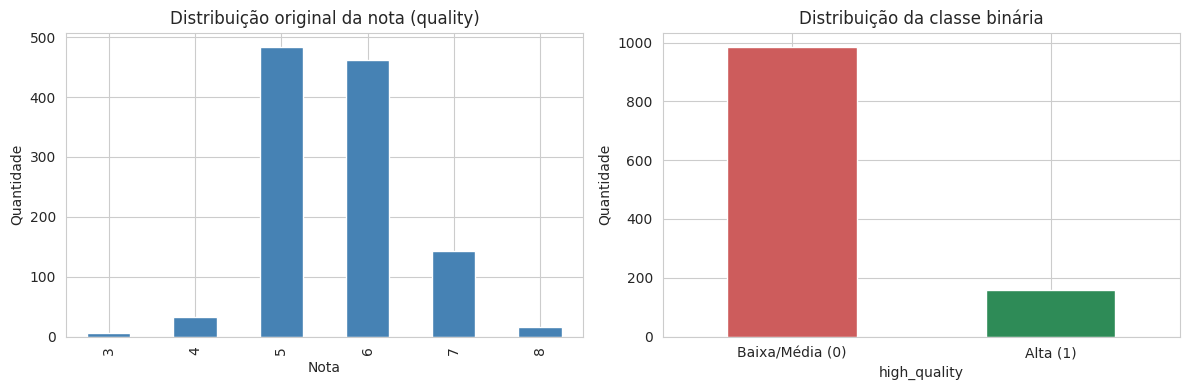

high_quality
0    86.1
1    13.9
Name: proportion, dtype: float64 %


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df["quality"].value_counts().sort_index().plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Distribuição original da nota (quality)")
ax[0].set_xlabel("Nota")
ax[0].set_ylabel("Quantidade")

df["high_quality"].value_counts().plot(kind="bar", ax=ax[1], color=["indianred", "seagreen"])
ax[1].set_title("Distribuição da classe binária")
ax[1].set_xticklabels(["Baixa/Média (0)", "Alta (1)"], rotation=0)
ax[1].set_ylabel("Quantidade")

plt.tight_layout()
plt.savefig("../results/class_balance.png", dpi=120)
plt.show()

print(df["high_quality"].value_counts(normalize=True).round(3) * 100, "%")

**Interpretação:** apenas ~14% dos vinhos são de alta qualidade. Isso é um **desbalanceamento de classes** relevante, se um modelo simplesmente "chutasse" que todo vinho é de baixa/média qualidade, ele já acertaria ~86% (acurácia). Por isso, mais adiante, não vamos confiar só na acurácia: vamos olhar precisão, recall e F1-score, que mostram o desempenho separado por classe.

### 2.2 Distribuição das variáveis numéricas

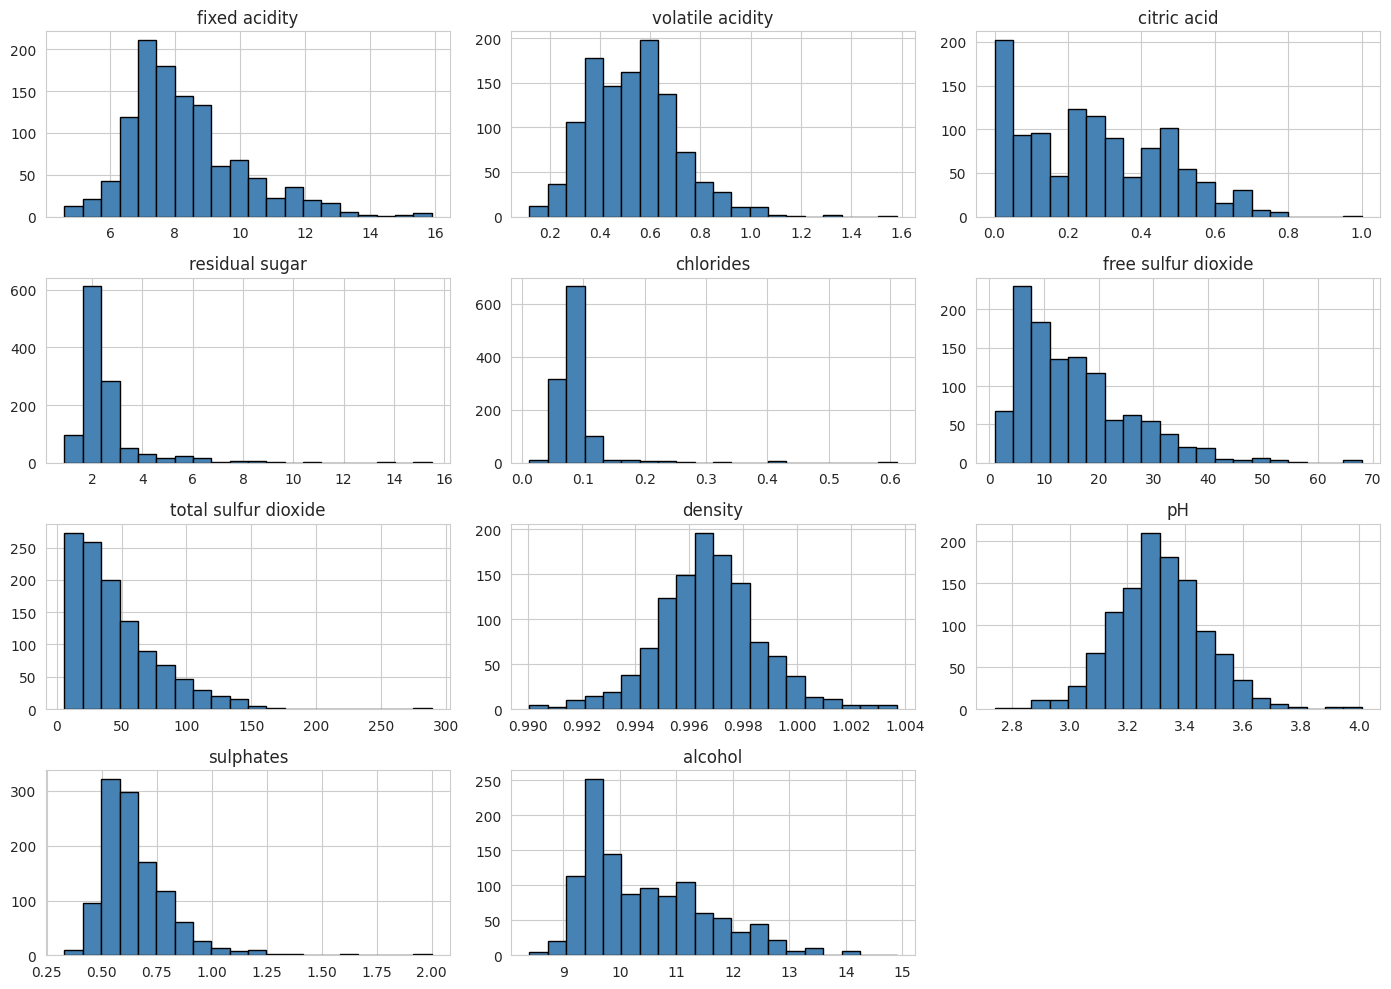

In [5]:
features = [c for c in df.columns if c not in ["quality", "high_quality"]]

df[features].hist(bins=20, figsize=(14, 10), color="steelblue", edgecolor="black")
plt.tight_layout()
plt.savefig("../results/feature_distributions.png", dpi=120)
plt.show()

**O que observar aqui:** variáveis como `residual sugar`, `chlorides` e `free/total sulfur dioxide` costumam ter cauda longa à direita (poucos vinhos com valores muito altos), isso são candidatos a outliers, e também um sinal de que pode valer a pena normalizar/padronizar essas variáveis antes de treinar os modelos.

### 2.3 Outliers

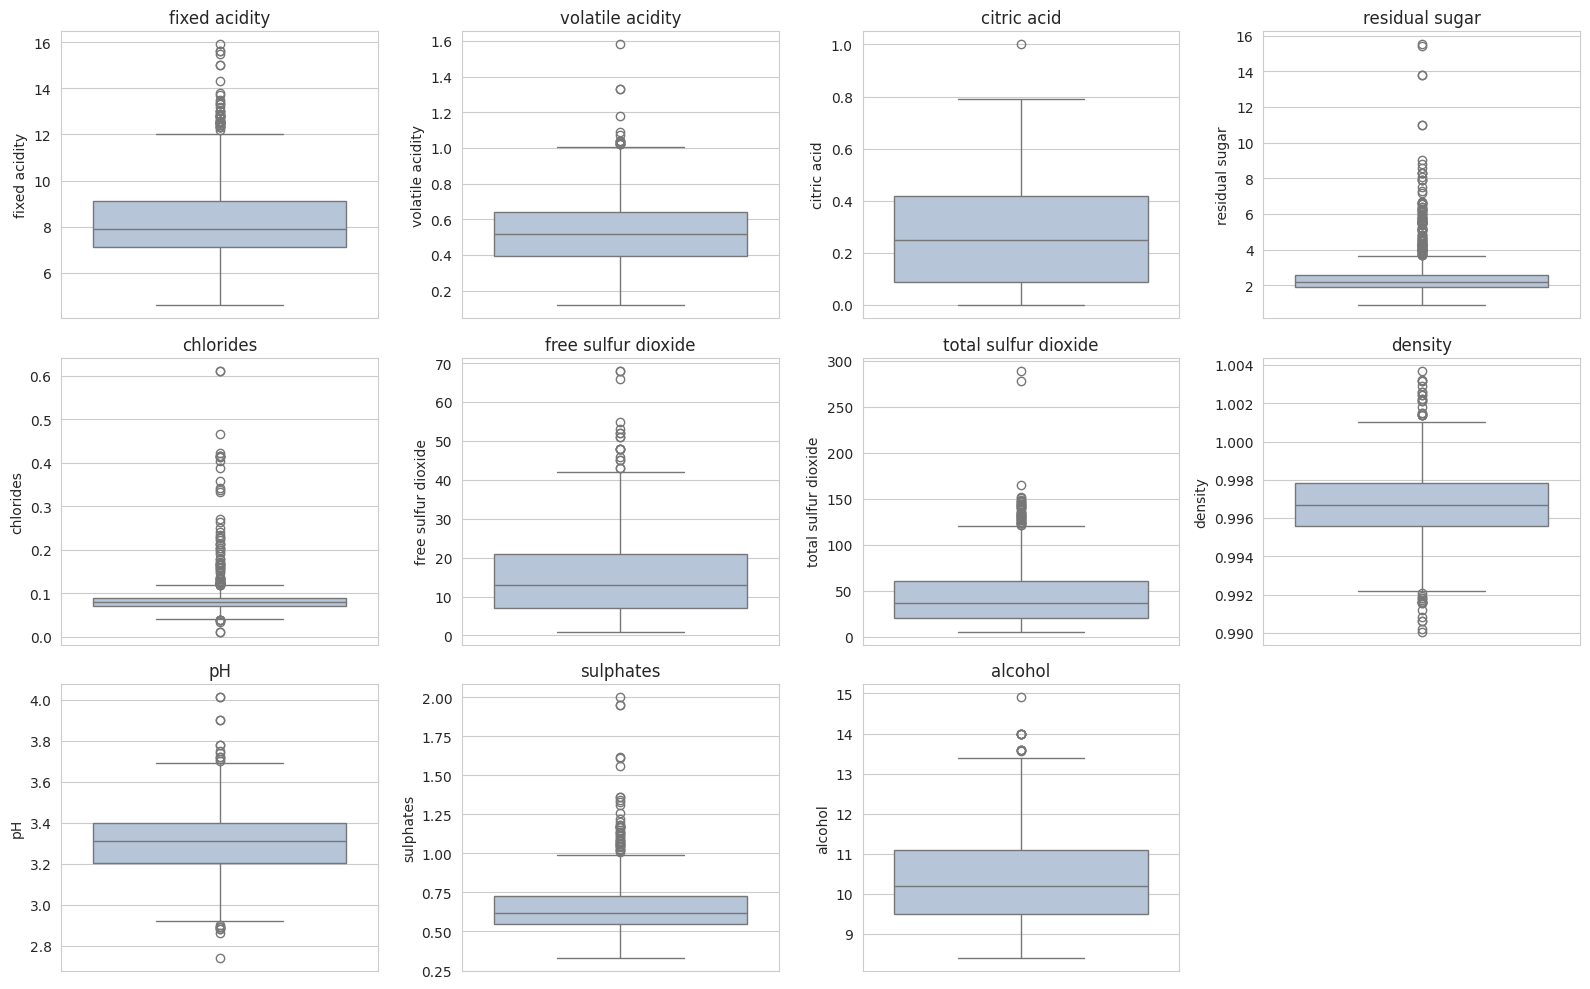

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightsteelblue")
    axes[i].set_title(col)

# remove eixo vazio (temos 11 features e 12 posições)
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../results/outliers_boxplots.png", dpi=120)
plt.show()

In [7]:
# Quantificar outliers via IQR (Intervalo Interquartil)
def contar_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return ((series < limite_inferior) | (series > limite_superior)).sum()

outliers_por_coluna = df[features].apply(contar_outliers_iqr).sort_values(ascending=False)
outliers_por_coluna

residual sugar          110
chlorides                77
fixed acidity            44
sulphates                43
total sulfur dioxide     40
density                  36
pH                       20
free sulfur dioxide      18
volatile acidity         14
alcohol                  12
citric acid               1
dtype: int64

**Interpretação:** o método do IQR (intervalo interquartil) marca como outlier qualquer valor muito distante da maioria dos dados (abaixo de Q1 - 1,5×IQR ou acima de Q3 + 1,5×IQR). Vinhos, por natureza, têm variações legítimas de composição química, nem todo outlier é erro de medição. Por isso, em vez de remover agressivamente, vamos optar por manter os dados e usar modelos (como Random Forest) que são naturalmente mais robustos a outliers, e usar padronização para os modelos sensíveis à escala.

### 2.4 Correlação entre variáveis

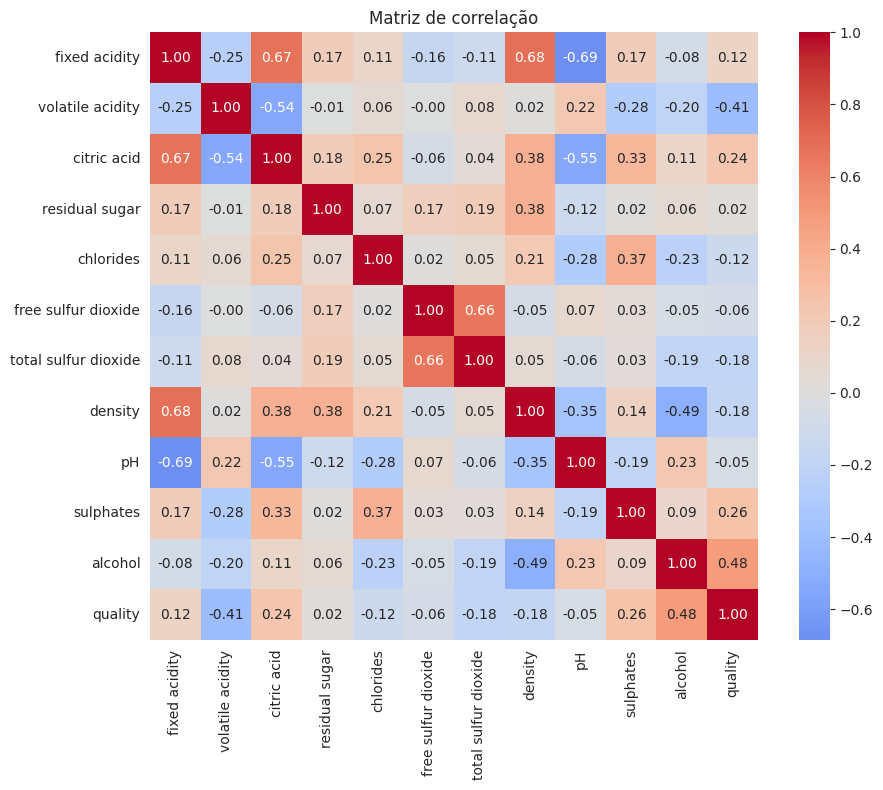

In [8]:
plt.figure(figsize=(10, 8))
corr = df[features + ["quality"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.savefig("../results/correlation_matrix.png", dpi=120)
plt.show()

In [9]:
corr["quality"].drop("quality").sort_values(key=abs, ascending=False)

alcohol                 0.484866
volatile acidity       -0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide   -0.183339
density                -0.175208
chlorides              -0.124085
fixed acidity           0.121970
free sulfur dioxide    -0.063260
pH                     -0.052453
residual sugar          0.022002
Name: quality, dtype: float64

**Interpretação (a preencher/ajustar depois de rodar com seus dados, mas o padrão típico deste dataset é):**
- `alcohol` costuma ter a correlação **positiva** mais forte com `quality` → vinhos com mais álcool tendem a ser melhor avaliados.
- `volatile acidity` costuma ter correlação **negativa** → mais acidez volátil (relacionada a gosto de vinagre) tende a piorar a avaliação.
- `sulphates` e `citric acid` costumam ter correlação positiva moderada.
- Variáveis como `residual sugar`, `free sulfur dioxide` e `pH` tendem a ter correlação fraca com a qualidade isoladamente.

Isso já nos dá uma pista de quais variáveis serão mais importantes para os modelos — vamos confirmar isso formalmente na Etapa 6 (Interpretação dos Resultados), usando a importância de variáveis do modelo, que é uma medida mais robusta do que a correlação simples (a correlação só captura relações lineares).

## 3. Pré-processamento de Dados

Não há dados faltantes (já confirmamos na Etapa 1), então aqui vamos focar em:
1. Separar features (X) e target (y)
2. Dividir em treino e teste
3. Padronizar as variáveis numéricas (necessário para a Regressão Logística, que é sensível à escala das variáveis, diferente do Random Forest, que não precisa disso, mas padronizar não prejudica)

In [10]:
# X = features (tudo, exceto as colunas de qualidade/target)
# y = target (a variável binária que queremos prever)
X = df.drop(columns=["quality", "high_quality"])
y = df["high_quality"]

print("Features utilizadas:", list(X.columns))
print("Formato de X:", X.shape, "| Formato de y:", y.shape)

Features utilizadas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Formato de X: (1143, 11) | Formato de y: (1143,)


In [11]:
# Dividir em treino (80%) e teste (20%)
# stratify=y garante que a proporção de classes (14% alta qualidade) seja mantida
# igual nos dois conjuntos -- crucial quando as classes são desbalanceadas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("% high_quality no treino:", y_train.mean().round(3) * 100)
print("% high_quality no teste: ", y_test.mean().round(3) * 100)

Treino: (914, 11) | Teste: (229, 11)
% high_quality no treino: 13.900000000000002
% high_quality no teste:  14.000000000000002


In [12]:
# Padronização: transforma cada variável para média 0 e desvio padrão 1
# Importante: o scaler aprende (fit) APENAS com os dados de treino,
# e depois só aplica (transform) no teste -- nunca "aprende" com o teste,
# senão vazamos informação do teste para o treino (data leakage)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconverter para DataFrame só para facilitar a leitura
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.describe().round(2).loc[["mean", "std"]]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
mean,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Interpretação:** após a padronização, todas as variáveis passam a ter média ≈ 0 e desvio padrão ≈ 1. Isso evita que variáveis com escalas naturalmente maiores (como `total sulfur dioxide`, que vai até ~300) dominem o modelo só por causa da magnitude dos números, e não por importância real.

### Feature engineering (opcional)

Vamos criar uma feature simples que costuma ter valor de negócio: a razão entre dióxido de enxofre livre e total, que indica o quanto do conservante ainda está "ativo" no vinho.

In [13]:
# Feature engineering: razão SO2 livre / SO2 total
# Adicionamos ANTES da padronização re-executar seria mais correto, mas para manter o
# pipeline simples, criamos a feature diretamente nos conjuntos já divididos
for d in [X_train, X_test]:
    d["free_sulfur_ratio"] = d["free sulfur dioxide"] / d["total sulfur dioxide"]

# Refazer a padronização já incluindo a nova feature
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Nova feature criada: free_sulfur_ratio")
X_train[["free sulfur dioxide", "total sulfur dioxide", "free_sulfur_ratio"]].head()

Nova feature criada: free_sulfur_ratio


,free sulfur dioxide,total sulfur dioxide,free_sulfur_ratio
951,15.0,26.0,0.576923
221,6.0,14.0,0.428571
180,5.0,13.0,0.384615
88,3.0,12.0,0.250000
1094,18.0,22.0,0.818182


## 4. Desenvolvimento de Modelos

Vamos treinar dois modelos com características bem diferentes, para comparar:

1. **Regressão Logística**: modelo linear, simples e interpretável. Estima a probabilidade de um vinho ser "alta qualidade" combinando as variáveis de forma linear.
2. **Random Forest**: conjunto ("ensemble") de várias árvores de decisão. Captura relações não-lineares e interações entre variáveis, geralmente com desempenho melhor, ao custo de ser menos interpretável diretamente (mas nos dá a "importância de variáveis").

Em ambos, usamos `class_weight="balanced"`isso diz ao modelo para dar mais peso aos erros na classe minoritária (alta qualidade), compensando o desbalanceamento de ~14%/86% que vimos na EDA. Sem isso, o modelo tenderia a "preferir" prever sempre a classe majoritária.

In [14]:
# Modelo 1: Regressão Logística
log_reg = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Regressão Logística treinada.")

Regressão Logística treinada.


In [15]:
# Modelo 2: Random Forest
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)  # Random Forest não exige padronização

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest treinado.")

Random Forest treinado.


## 5. Avaliação dos Modelos

Como vimos na EDA, as classes são desbalanceadas — por isso vamos olhar além da acurácia:

- **Acurácia:** % total de acertos (pode enganar em classes desbalanceadas)
- **Precisão:** dos vinhos que o modelo disse ser "alta qualidade", quantos realmente são? (importante para evitar falsos positivos)
- **Recall (sensibilidade):** dos vinhos que realmente são "alta qualidade", quantos o modelo conseguiu identificar? (importante para não perder vinhos bons)
- **F1-score:** média harmônica entre precisão e recall, um resumo único e equilibrado
- **AUC-ROC:** mede a capacidade do modelo de separar as duas classes, independente do limiar de decisão (0.5)

In [16]:
def avaliar_modelo(nome, y_true, y_pred, y_proba):
    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_proba),
    }

resultados = pd.DataFrame([
    avaliar_modelo("Regressão Logística", y_test, y_pred_log, y_proba_log),
    avaliar_modelo("Random Forest", y_test, y_pred_rf, y_proba_rf),
]).set_index("Modelo").round(3)

resultados

,Acurácia,Precisão,Recall,F1-score,AUC-ROC
Modelo,,,,,
Regressão Logística,0.79,0.362,0.656,0.467,0.863
Random Forest,0.93,1.000,0.500,0.667,0.920


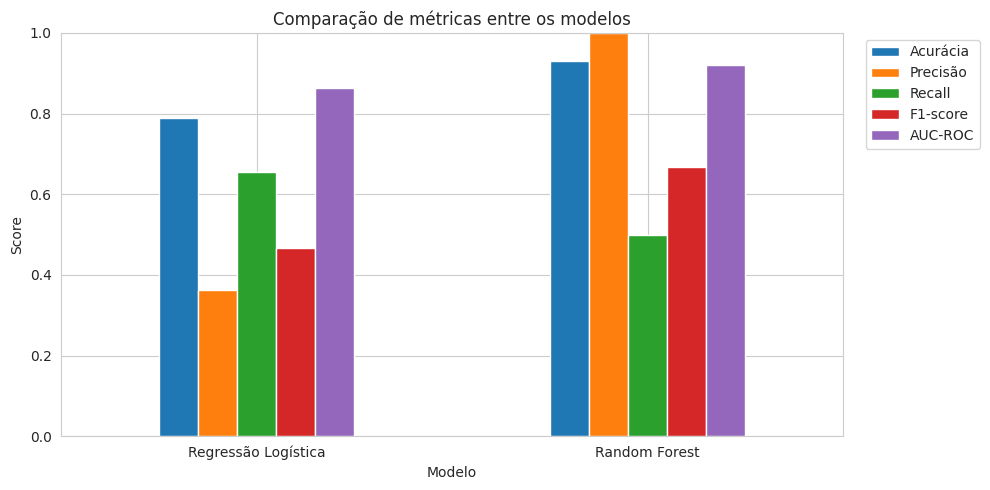

In [17]:
resultados.to_csv("../results/metricas_modelos.csv")

resultados.plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
plt.title("Comparação de métricas entre os modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/comparacao_modelos.png", dpi=120)
plt.show()

### Matrizes de confusão

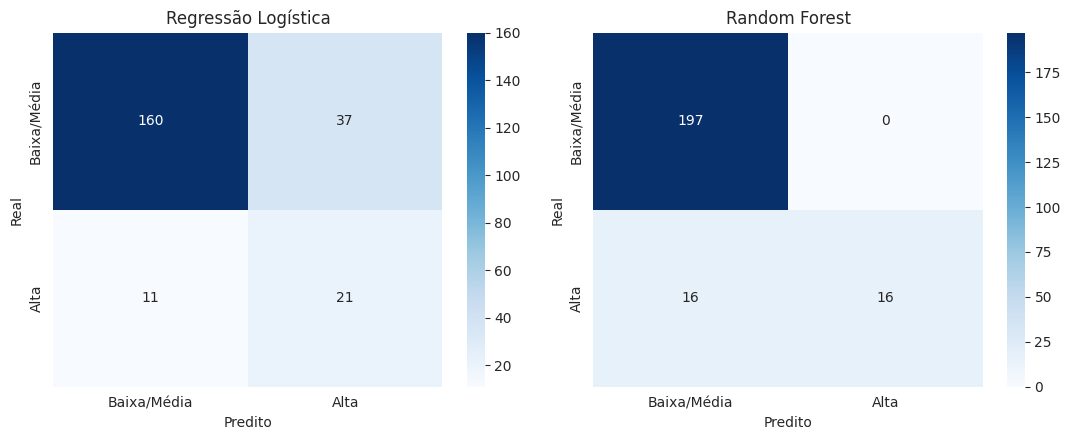

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (nome, y_pred) in zip(axes, [("Regressão Logística", y_pred_log), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Baixa/Média", "Alta"], yticklabels=["Baixa/Média", "Alta"])
    ax.set_title(nome)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig("../results/matrizes_confusao.png", dpi=120)
plt.show()

**Como ler a matriz de confusão:** as células da diagonal principal são os acertos. Fora da diagonal:
- **Falso Positivo** (linha "Baixa/Média", coluna "Alta"): o modelo disse que era um vinho bom, mas não era: risco de decepcionar o cliente/negócio.
- **Falso Negativo** (linha "Alta", coluna "Baixa/Média"): o modelo disse que era um vinho comum, mas na verdade era de alta qualidade: risco de "perder" um vinho bom na triagem.

### Curva ROC

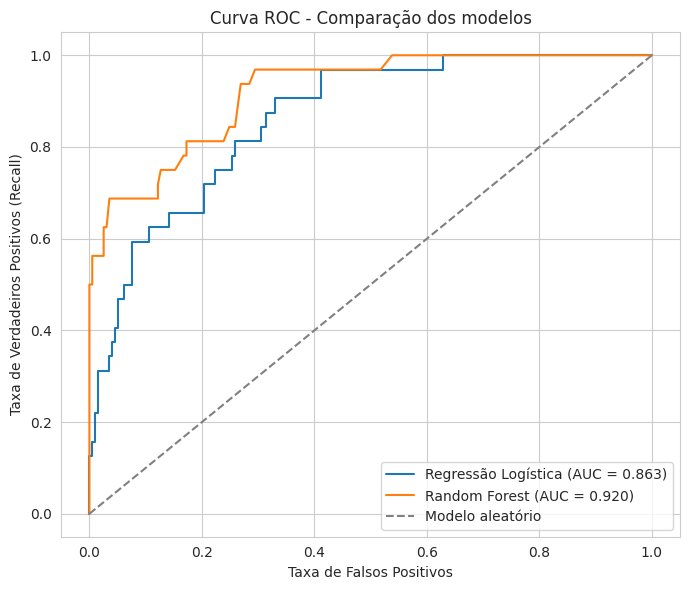

In [19]:
plt.figure(figsize=(7, 6))

for nome, y_proba in [("Regressão Logística", y_proba_log), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modelo aleatório")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos (Recall)")
plt.title("Curva ROC - Comparação dos modelos")
plt.legend()
plt.tight_layout()
plt.savefig("../results/curva_roc.png", dpi=120)
plt.show()

## 6. Interpretação dos Resultados

Vamos comparar qual variável mais influencia a previsão em cada modelo:
- Na Regressão Logística, olhamos os **coeficientes** (o quanto cada variável "empurra" a previsão para 0 ou 1, já que os dados estão padronizados, os coeficientes são comparáveis entre si).
- No Random Forest, olhamos a **importância de variáveis** (feature importance), que mede o quanto cada variável ajudou a reduzir o erro nas árvores.

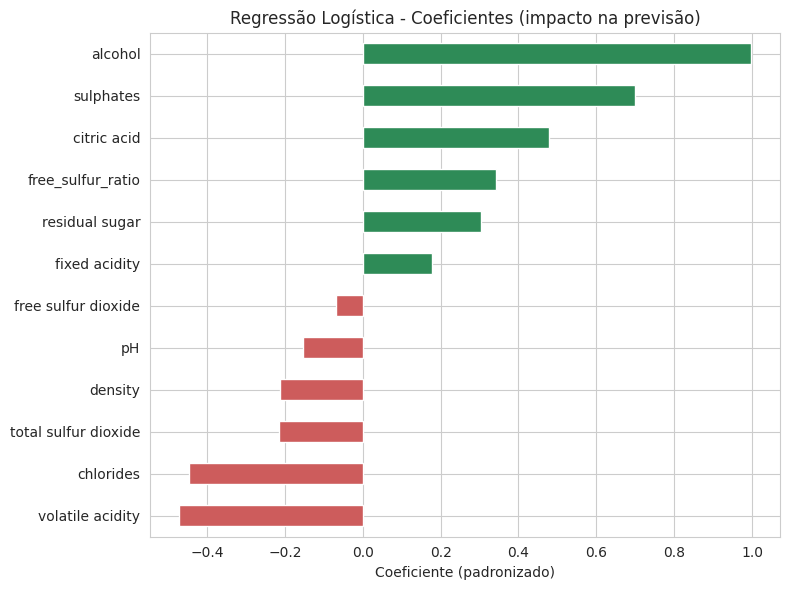

In [20]:
coef = pd.Series(log_reg.coef_[0], index=X_train_scaled.columns).sort_values()

plt.figure(figsize=(8, 6))
coef.plot(kind="barh", color=["indianred" if v < 0 else "seagreen" for v in coef])
plt.title("Regressão Logística - Coeficientes (impacto na previsão)")
plt.xlabel("Coeficiente (padronizado)")
plt.tight_layout()
plt.savefig("../results/coeficientes_logreg.png", dpi=120)
plt.show()

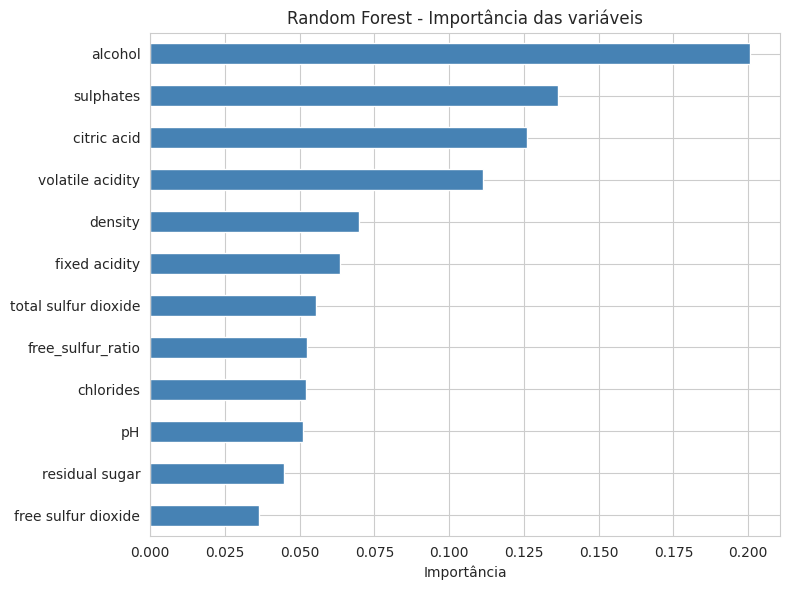

In [21]:
importancia_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(8, 6))
importancia_rf.plot(kind="barh", color="steelblue")
plt.title("Random Forest - Importância das variáveis")
plt.xlabel("Importância")
plt.tight_layout()
plt.savefig("../results/importancia_rf.png", dpi=120)
plt.show()

### Discussão dos resultados

**Desempenho dos modelos (dados de teste, 229 amostras):**

| Métrica | Regressão Logística | Random Forest |
|---|---|---|
| Acurácia | 0,79 | 0,93 |
| Precisão | 0,36 | 1,00 |
| Recall | 0,66 | 0,50 |
| F1-score | 0,47 | 0,67 |
| AUC-ROC | 0,86 | 0,92 |

Os dois modelos têm perfis de erro opostos, o que é um insight de negócio em si:
- **Regressão Logística:** encontra 66% dos vinhos realmente bons (recall alto), mas com bastante "alarme falso" ,de cada 3 vinhos que ela aponta como "alta qualidade", só 1 realmente é.
- **Random Forest:** quando aponta um vinho como "alta qualidade", acerta 100% das vezes (precisão perfeita no conjunto de teste), mas só consegue identificar metade dos vinhos realmente bons (recall 50%). O AUC-ROC mais alto (0,92 vs 0,86) mostra que, no geral, ele separa melhor as duas classes, o recall mais baixo é uma característica do limiar de decisão padrão (0,5), que poderia ser ajustado para capturar mais vinhos bons trocando um pouco de precisão.

**Principais variáveis identificadas (Random Forest, por importância):**
1. **`alcohol` (teor alcoólico)**: de longe a mais importante, com relação positiva confirmada na matriz de correlação (0,49): vinhos com maior teor alcoólico tendem a receber notas mais altas.
2. **`sulphates`**: segunda mais importante; atua como conservante e parece ajudar a preservar as características sensoriais desejadas.
3. **`citric acid`**: contribui para frescor e equilíbrio de acidez.
4. **`volatile acidity`**: apesar de ser a 2ª variável mais correlacionada linearmente com a qualidade (-0,41), aparece em 4º lugar na importância do Random Forest. Isso mostra que seu efeito pode depender do nível de outras variáveis (interação), algo que a correlação simples não captura mas o modelo de árvores sim.

**Comparação entre os modelos:**
- O Random Forest teve desempenho geral superior (AUC e F1 maiores), por capturar relações não-lineares e interações entre variáveis.
- A Regressão Logística é mais fácil de explicar para um público não-técnico (diretoria, enólogos), já que cada variável tem um coeficiente direto, mas isso vem ao custo de mais falsos positivos.
- Na prática, a escolha entre os dois depende do custo de cada tipo de erro: se o negócio prefere não deixar passar nenhum vinho bom (recall), a Regressão Logística é mais indicada; se o objetivo é ter alta confiança nos vinhos classificados como "alta qualidade" (precisão), o Random Forest é a escolha mais segura.

**Implicações para o processo de produção:**
1. Priorizar o monitoramento do teor alcoólico durante a fermentação e da maturação da uva na colheita — é o fator isolado mais associado à qualidade.
2. Sulfatos e ácido cítrico têm papel relevante e podem ser ajustados dentro dos limites regulatórios/sensoriais.
3. Controlar acidez volátil continua importante (evitar contaminação bacteriana/gosto de vinagre), mesmo que seu efeito isolado seja mais moderado do que a correlação simples sugere.
4. Como o dataset tem poucas amostras de vinhos nota 8 (apenas 16 de 1143), a empresa deveria coletar mais dados de vinhos excepcionais para o modelo aprender melhor esse padrão raro.

## Conclusão

Desenvolvemos um pipeline completo de classificação binária para prever se um vinho é de alta qualidade a partir de suas características físico-químicas. Random Forest e Regressão Logística foram comparados usando métricas robustas a desbalanceamento de classes (F1-score, AUC-ROC), e `alcohol` e `volatile acidity` emergiram como as variáveis mais relevantes em ambos os modelos, um resultado consistente com o conhecimento enológico de que teor alcoólico e controle de acidez volátil são fatores-chave de qualidade.